# 📊 EDA — Engagement Score V1: IDF Basic (Mba Ocim)

**Metodologi:** Invers Weight menggunakan formula IDF dasar tanpa smoothing

$$IDF = \log_2 \frac{N}{DF}$$

| Variabel | Definisi |
|---|---|
| **N** | Rata-rata faktor per hari = total nilai faktor / TimeFrame (hari) |
| **DF** | Total post dalam timeframe |

**Formula Akhir:**
$$\text{Engagement Score} = \sum (\text{nilai\_faktor} \times \text{bobot\_faktor})$$

| Platform | Faktor |
|---|---|
| Facebook | Likes, Comment, Shares |
| Twitter | Likes, Reply, Retweet |
| Instagram | Likes, Reply |
| TikTok | Likes, Shares, Comment, Play Count |
| YouTube | Likes+Dislikes, Reply, View |
| Threads | Shares, Reply, Repost, Quote, Likes |

In [1]:
import json
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi plot
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')
COLORS = {
    'facebook': '#1877F2', 'twitter': '#1DA1F2',
    'instagram': '#E1306C', 'tiktok': '#010101',
    'youtube': '#FF0000', 'threads': '#000000'
}

BASE_PATH = Path(r'D:/SPECTRA/Riset_enggagement/top100_raw_20260805')
PLATFORMS = ['facebook', 'twitter', 'instagram', 'tiktok', 'youtube', 'threads']
print('✅ Setup selesai')

✅ Setup selesai


## 1️⃣ Load & Parsing Data per Platform

In [2]:
def extract_facebook(raw):
    """Ekstrak fields: likes, comment, shares dari JSON Facebook"""
    def safe_get(d, *keys, default=0):
        for k in keys:
            if isinstance(d, dict): d = d.get(k, {})
            elif isinstance(d, list): d = d[0] if d else {}
            else: return default
        return d if isinstance(d, (int, float)) else default

    likes = safe_get(raw, 'feedback', 'reaction_count', 'count')
    comment = safe_get(raw, 'feedback', 'comments_count_reduced', 'count')
    shares = safe_get(raw, 'feedback', 'share_count', 'count')
    post_id = raw.get('id', raw.get('post_id', 'unknown'))
    return {'post_id': post_id, 'likes': likes, 'comment': comment, 'shares': shares}

def extract_twitter(raw):
    """Ekstrak fields: favorite_count (likes), reply_count, retweet_count dari Twitter"""
    legacy = raw.get('legacy', {})
    views = raw.get('views', {})
    likes = legacy.get('favorite_count', 0) or 0
    reply = legacy.get('reply_count', 0) or 0
    retweet = legacy.get('retweet_count', 0) or 0
    views_count = int(views.get('count', 0) or 0)
    post_id = raw.get('rest_id', 'unknown')
    return {'post_id': post_id, 'likes': likes, 'reply': reply, 'retweet': retweet, 'views': views_count}

def extract_instagram(raw):
    """Ekstrak fields: like_count, comment_count dari Instagram"""
    likes = raw.get('like_count', 0) or 0
    comment = raw.get('comment_count', 0) or 0
    post_id = raw.get('pk', raw.get('id', 'unknown'))
    return {'post_id': post_id, 'likes': likes, 'reply': comment}

def extract_tiktok(raw):
    """Ekstrak fields: digg_count(likes), share_count, comment_count, play_count"""
    likes = raw.get('digg_count', 0) or 0
    shares = raw.get('share_count', 0) or 0
    comment = raw.get('comment_count', 0) or 0
    play_count = raw.get('play_count', 0) or 0
    post_id = raw.get('id', 'unknown')
    return {'post_id': post_id, 'likes': likes, 'shares': shares, 'comment': comment, 'play_count': play_count}

def extract_youtube(raw):
    """Ekstrak fields: likes, replies(comments), views dari YouTube"""
    likes = raw.get('likes', 0) or 0
    views = raw.get('views', 0) or 0
    comments = raw.get('commentCount', raw.get('comments', 0)) or 0
    post_id = raw.get('id', raw.get('url', 'unknown'))
    return {'post_id': post_id, 'likes': likes, 'reply': comments, 'views': views}

def extract_threads(raw):
    """Ekstrak fields: like_count, reply, repost_count, quote_count, reshare_count dari Threads"""
    tpi = raw.get('text_post_app_info', {})
    likes = raw.get('like_count', 0) or 0
    reply = tpi.get('direct_reply_count', 0) or 0
    repost = tpi.get('repost_count', 0) or 0
    quote = tpi.get('quote_count', 0) or 0
    shares = tpi.get('reshare_count', 0) or 0
    post_id = raw.get('pk', raw.get('id', 'unknown'))
    return {'post_id': post_id, 'likes': likes, 'reply': reply, 'repost': repost, 'quote': quote, 'shares': shares}

EXTRACTORS = {
    'facebook': extract_facebook, 'twitter': extract_twitter,
    'instagram': extract_instagram, 'tiktok': extract_tiktok,
    'youtube': extract_youtube, 'threads': extract_threads
}

def load_platform(platform):
    path = BASE_PATH / platform
    records = []
    extractor = EXTRACTORS[platform]
    for fp in glob.glob(str(path / '*.json')):
        try:
            with open(fp, encoding='utf-8') as f:
                raw = json.load(f)
            if isinstance(raw, list):
                for item in raw:
                    records.append(extractor(item))
            elif isinstance(raw, dict):
                records.append(extractor(raw))
        except Exception as e:
            pass
    df = pd.DataFrame(records)
    df['platform'] = platform
    return df

dfs = {p: load_platform(p) for p in PLATFORMS}
for p, df in dfs.items():
    print(f'{p:12s} → {len(df):4d} posts | columns: {list(df.columns)}')

facebook     →  100 posts | columns: ['post_id', 'likes', 'comment', 'shares', 'platform']
twitter      →  100 posts | columns: ['post_id', 'likes', 'reply', 'retweet', 'views', 'platform']
instagram    →  100 posts | columns: ['post_id', 'likes', 'reply', 'platform']
tiktok       →  100 posts | columns: ['post_id', 'likes', 'shares', 'comment', 'play_count', 'platform']
youtube      →  100 posts | columns: ['post_id', 'likes', 'reply', 'views', 'platform']
threads      →  100 posts | columns: ['post_id', 'likes', 'reply', 'repost', 'quote', 'shares', 'platform']


## 2️⃣ Statistik Deskriptif per Platform

In [3]:
print('='*70)
for p, df in dfs.items():
    eng_cols = [c for c in df.columns if c not in ['post_id', 'platform']]
    print(f'\n📌 {p.upper()}')
    print(df[eng_cols].describe().round(2).to_string())
    print('-'*70)


📌 FACEBOOK
       likes  comment  shares
count  100.0    100.0   100.0
mean     0.0      0.0     0.0
std      0.0      0.0     0.0
min      0.0      0.0     0.0
25%      0.0      0.0     0.0
50%      0.0      0.0     0.0
75%      0.0      0.0     0.0
max      0.0      0.0     0.0
----------------------------------------------------------------------

📌 TWITTER
          likes    reply  retweet       views
count    100.00   100.00   100.00      100.00
mean    1791.94   152.85   407.46   184672.66
std     3976.47   328.83  1017.34   307654.85
min        6.00     0.00     0.00    15626.00
25%       44.75     6.00     9.00    37597.00
50%      194.00    33.50    41.00    76876.50
75%     1001.00   127.75   211.25   178924.75
max    20848.00  1808.00  5771.00  2500349.00
----------------------------------------------------------------------

📌 INSTAGRAM
           likes     reply
count     100.00    100.00
mean    28597.78   1440.08
std     45324.89   1877.96
min       977.00     19.00
25%

## 3️⃣ Distribusi Engagement Metrics (Boxplot per Platform)

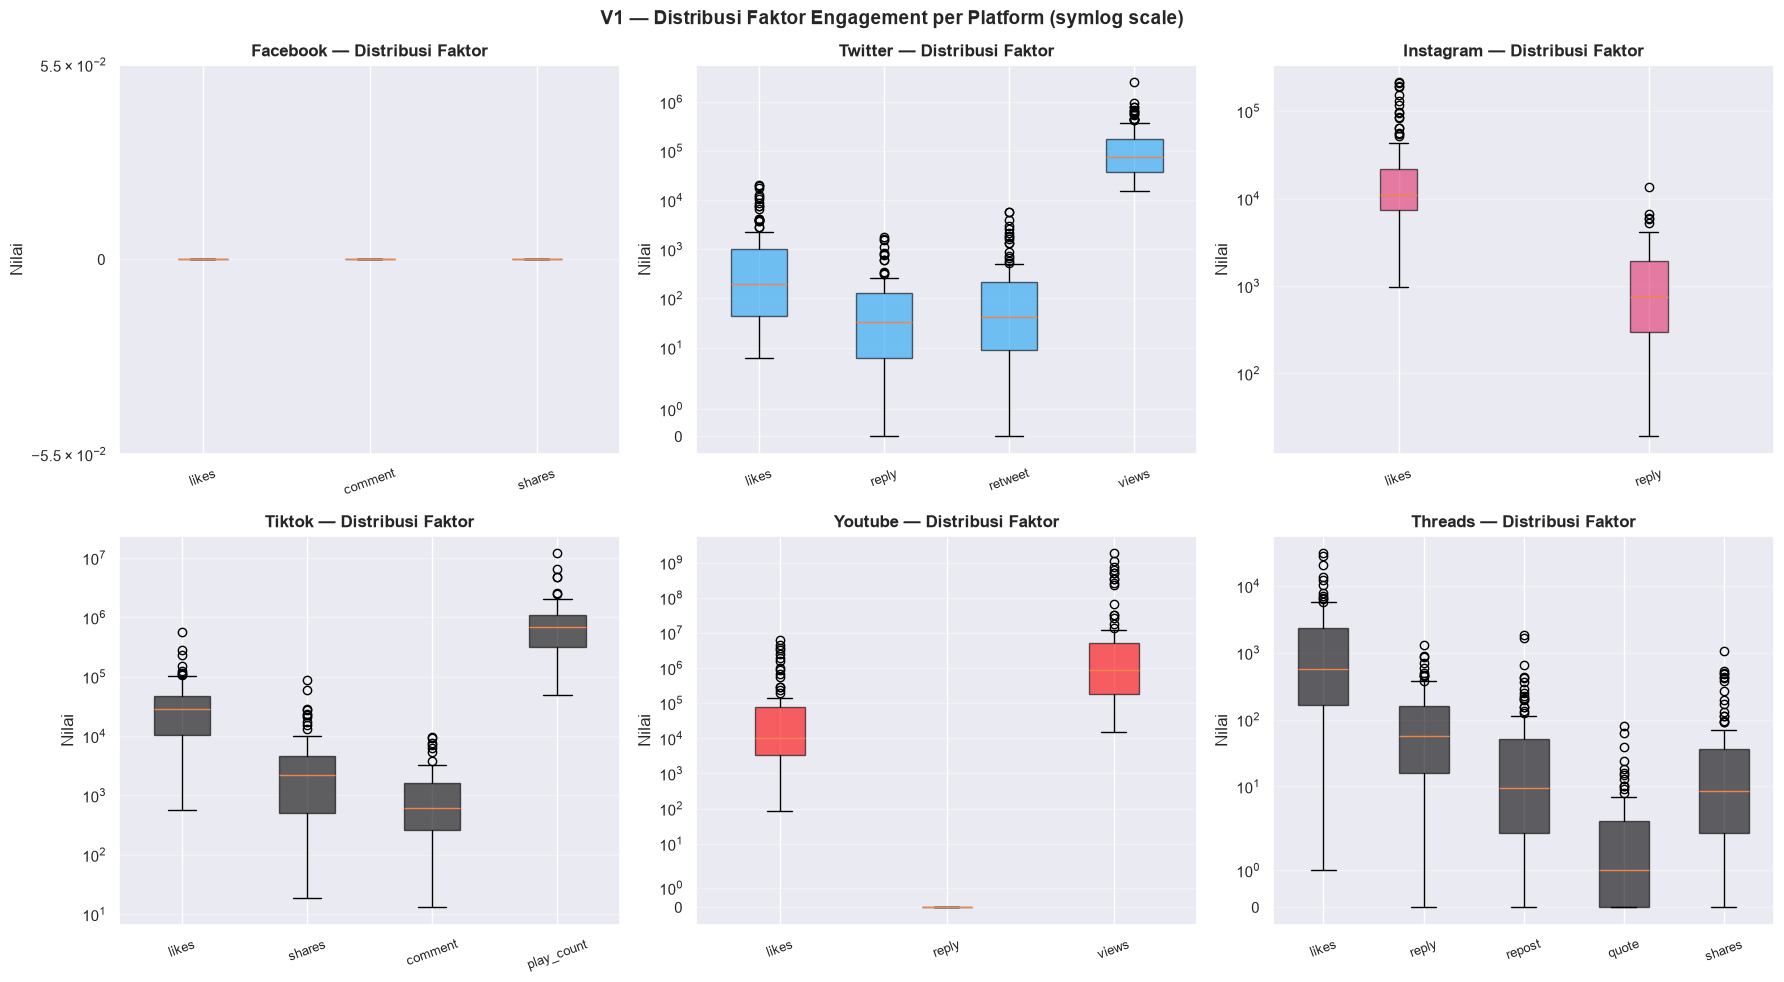

✅ Plot disimpan: eda_v1_distribusi_faktor.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (plat, df) in enumerate(dfs.items()):
    ax = axes[i]
    eng_cols = [c for c in df.columns if c not in ['post_id', 'platform']]
    data_plot = [df[c].dropna() for c in eng_cols]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False)
    color = COLORS[plat]
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticklabels(eng_cols, rotation=20, fontsize=9)
    ax.set_title(f'{plat.capitalize()} — Distribusi Faktor', fontweight='bold')
    ax.set_ylabel('Nilai')
    ax.set_yscale('symlog')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('V1 — Distribusi Faktor Engagement per Platform (symlog scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_v1_distribusi_faktor.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot disimpan: eda_v1_distribusi_faktor.png')

## 4️⃣ Perhitungan IDF V1 & Engagement Score per Platform

In [5]:
# V1: IDF = log2(N / DF)
# N   = rata-rata nilai faktor per hari → diasumsikan total posts = 1 timeframe
# DF  = total post dalam timeframe

TIMEFRAME_DAYS = 1  # Asumsi: data 1 hari

results_v1 = {}

for plat, df in dfs.items():
    eng_cols = [c for c in df.columns if c not in ['post_id', 'platform']]
    N_total = len(df)          # DF = total post
    DF = N_total
    
    idf_weights = {}
    for col in eng_cols:
        N_factor = df[col].sum() / TIMEFRAME_DAYS  # rata-rata per hari
        if DF > 0 and N_factor > 0:
            idf = np.log2(N_factor / DF)
        else:
            idf = 0.0  # ⚠️ V1 rawan division-by-zero!
        idf_weights[col] = idf
    
    # Normalisasi bobot (min-max ke [0,1])
    vals = np.array(list(idf_weights.values()))
    if vals.max() != vals.min():
        norm_weights = {k: (v - vals.min()) / (vals.max() - vals.min()) for k, v in idf_weights.items()}
    else:
        norm_weights = {k: 1/len(idf_weights) for k in idf_weights}
    
    # Engagement Score = sum(nilai_faktor x bobot_faktor)
    score_series = pd.Series(0.0, index=df.index)
    for col, w in norm_weights.items():
        score_series += df[col].fillna(0) * w
    
    df_out = df.copy()
    df_out['engagement_score_v1'] = score_series
    results_v1[plat] = {
        'df': df_out,
        'idf_raw': idf_weights,
        'idf_norm': norm_weights,
        'DF': DF
    }

# Tampilkan IDF weights
print('='*65)
print('📐 IDF WEIGHTS V1 (log2(N/DF)) — Raw & Normalized')
print('='*65)
for plat, res in results_v1.items():
    print(f'\n🔵 {plat.upper()} (DF={res["DF"]} posts)')
    for factor, w_raw in res['idf_raw'].items():
        w_norm = res['idf_norm'][factor]
        print(f'   {factor:15s} → IDF_raw={w_raw:8.4f}  |  IDF_norm={w_norm:.4f}')

📐 IDF WEIGHTS V1 (log2(N/DF)) — Raw & Normalized

🔵 FACEBOOK (DF=100 posts)
   likes           → IDF_raw=  0.0000  |  IDF_norm=0.3333
   comment         → IDF_raw=  0.0000  |  IDF_norm=0.3333
   shares          → IDF_raw=  0.0000  |  IDF_norm=0.3333

🔵 TWITTER (DF=100 posts)
   likes           → IDF_raw= 10.8073  |  IDF_norm=0.3469
   reply           → IDF_raw=  7.2560  |  IDF_norm=0.0000
   retweet         → IDF_raw=  8.6705  |  IDF_norm=0.1382
   views           → IDF_raw= 17.4946  |  IDF_norm=1.0000

🔵 INSTAGRAM (DF=100 posts)
   likes           → IDF_raw= 14.8036  |  IDF_norm=1.0000
   reply           → IDF_raw= 10.4919  |  IDF_norm=0.0000

🔵 TIKTOK (DF=100 posts)
   likes           → IDF_raw= 15.4545  |  IDF_norm=0.5339
   shares          → IDF_raw= 12.3985  |  IDF_norm=0.2153
   comment         → IDF_raw= 10.3336  |  IDF_norm=0.0000
   play_count      → IDF_raw= 19.9249  |  IDF_norm=1.0000

🔵 YOUTUBE (DF=100 posts)
   likes           → IDF_raw= 18.2030  |  IDF_norm=0.6992
   repl

## 5️⃣ Rumus Akhir: Engagement Score per Platform (V1)

In [6]:
print('='*75)
print('🧮 RUMUS AKHIR ENGAGEMENT SCORE V1 PER PLATFORM')
print('   Formula: Engagement_Score = Σ (nilai_faktor × IDF_norm_faktor)')
print('='*75)

formula_v1 = {
    'facebook':  'ES_fb  = likes×{likes:.4f}  + comment×{comment:.4f}  + shares×{shares:.4f}',
    'twitter':   'ES_tw  = likes×{likes:.4f}  + reply×{reply:.4f}     + retweet×{retweet:.4f}',
    'instagram': 'ES_ig  = likes×{likes:.4f}  + reply×{reply:.4f}',
    'tiktok':    'ES_tt  = likes×{likes:.4f}  + shares×{shares:.4f}   + comment×{comment:.4f}  + play_count×{play_count:.4f}',
    'youtube':   'ES_yt  = likes×{likes:.4f}  + reply×{reply:.4f}     + views×{views:.4f}',
    'threads':   'ES_th  = likes×{likes:.4f}  + reply×{reply:.4f}     + repost×{repost:.4f}    + quote×{quote:.4f}   + shares×{shares:.4f}'
}

for plat, tmpl in formula_v1.items():
    w = results_v1[plat]['idf_norm']
    try:
        formula_str = tmpl.format(**w)
    except KeyError as e:
        formula_str = f'[⚠️ missing key {e}]'
    print(f'\n📌 {plat.upper()}')
    print(f'   {formula_str}')
print('\n⚠️ Catatan V1: Rawan division-by-zero / log(0) jika DF=0 atau N=0')

🧮 RUMUS AKHIR ENGAGEMENT SCORE V1 PER PLATFORM
   Formula: Engagement_Score = Σ (nilai_faktor × IDF_norm_faktor)

📌 FACEBOOK
   ES_fb  = likes×0.3333  + comment×0.3333  + shares×0.3333

📌 TWITTER
   ES_tw  = likes×0.3469  + reply×0.0000     + retweet×0.1382

📌 INSTAGRAM
   ES_ig  = likes×1.0000  + reply×0.0000

📌 TIKTOK
   ES_tt  = likes×0.5339  + shares×0.2153   + comment×0.0000  + play_count×1.0000

📌 YOUTUBE
   ES_yt  = likes×0.6992  + reply×0.0000     + views×1.0000

📌 THREADS
   ES_th  = likes×1.0000  + reply×0.5400     + repost×0.4773    + quote×0.0000   + shares×0.4186

⚠️ Catatan V1: Rawan division-by-zero / log(0) jika DF=0 atau N=0


## 6️⃣ Distribusi Engagement Score V1 per Platform

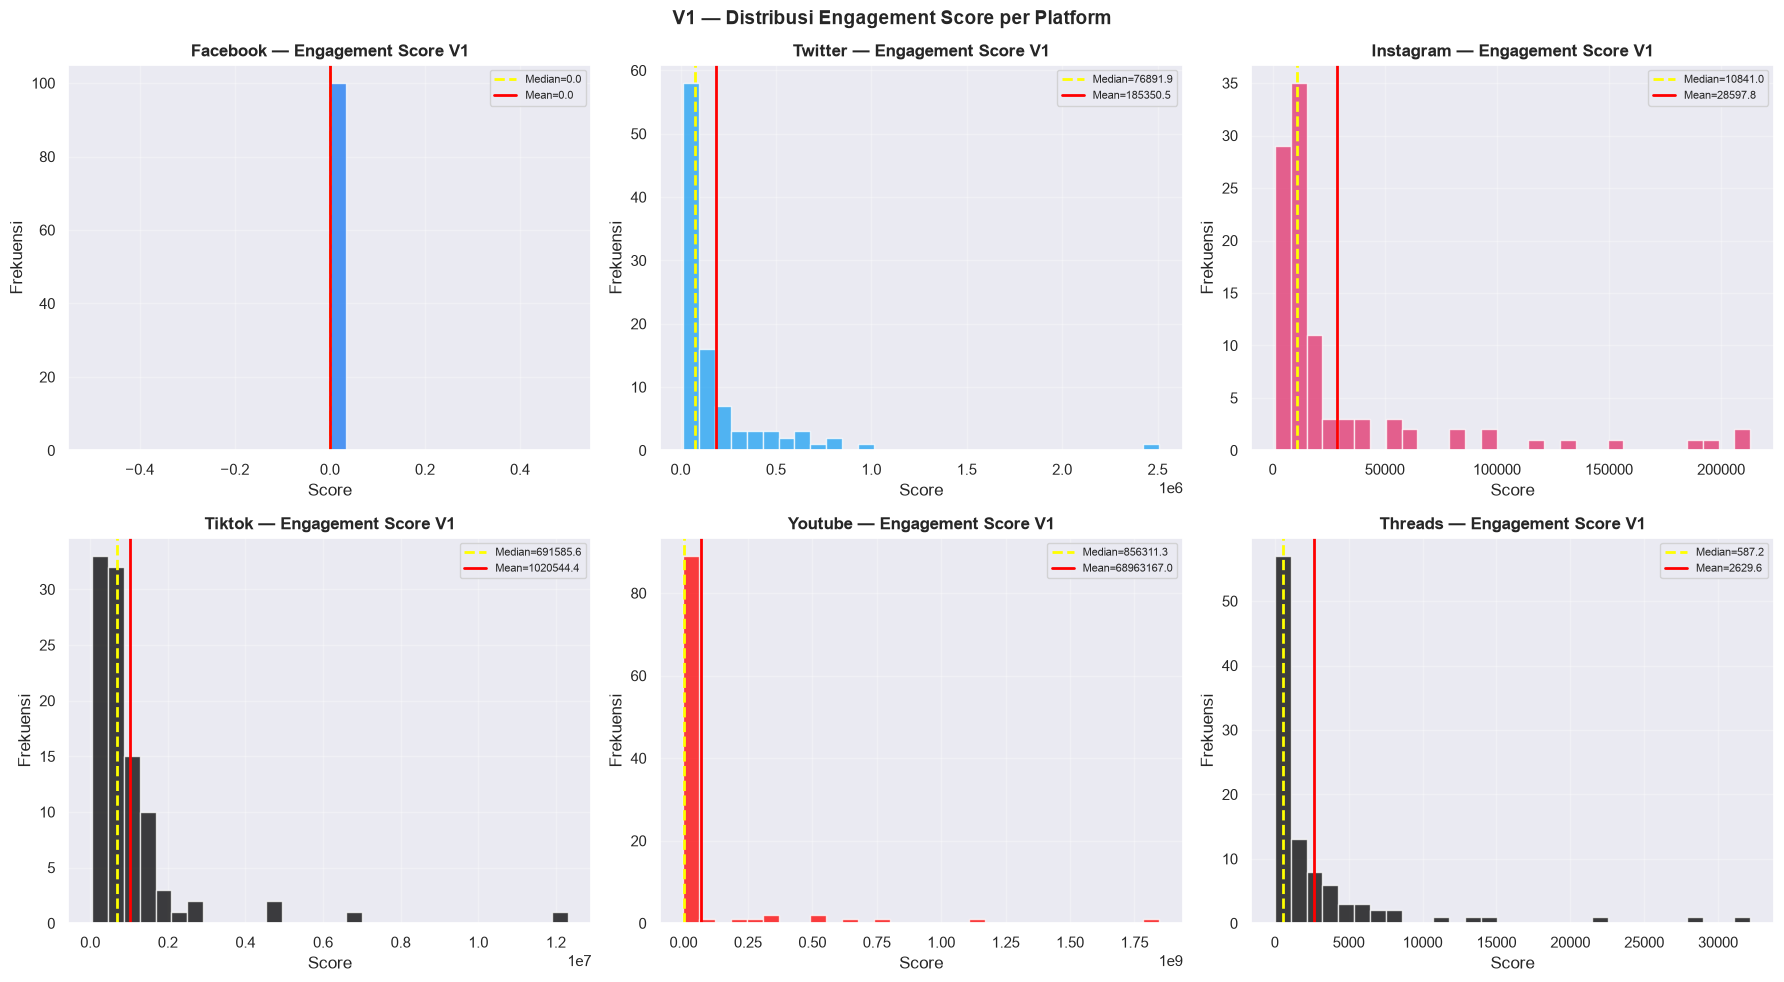

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (plat, res) in enumerate(results_v1.items()):
    ax = axes[i]
    scores = res['df']['engagement_score_v1'].dropna()
    ax.hist(scores, bins=30, color=COLORS[plat], alpha=0.75, edgecolor='white')
    ax.axvline(scores.median(), color='yellow', lw=2, linestyle='--', label=f'Median={scores.median():.1f}')
    ax.axvline(scores.mean(), color='red', lw=2, linestyle='-', label=f'Mean={scores.mean():.1f}')
    ax.set_title(f'{plat.capitalize()} — Engagement Score V1', fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('V1 — Distribusi Engagement Score per Platform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_v1_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7️⃣ Perbandingan Rata-rata Engagement Score Antar Platform


📊 RINGKASAN ENGAGEMENT SCORE V1
           N Posts   Mean Score  Median Score     Max Score     Std Score
Platform                                                                 
Facebook       100         0.00          0.00  0.000000e+00  0.000000e+00
Twitter        100    185350.50      76891.86  2.507170e+06  3.084167e+05
Instagram      100     28597.78      10841.00  2.129910e+05  4.532489e+04
Tiktok         100   1020544.40     691585.57  1.230110e+07  1.508146e+06
Youtube        100  68963167.02     856311.32  1.844782e+09  2.472261e+08
Threads        100      2629.59        587.16  3.217796e+04  5.247570e+03


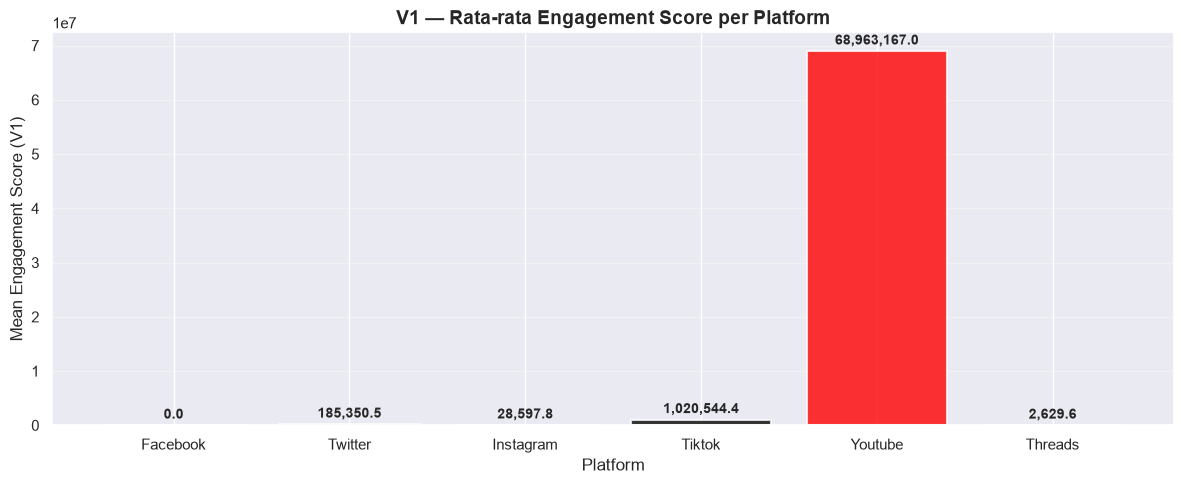

In [8]:
summary = []
for plat, res in results_v1.items():
    s = res['df']['engagement_score_v1']
    summary.append({
        'Platform': plat.capitalize(),
        'N Posts': len(res['df']),
        'Mean Score': s.mean().round(2),
        'Median Score': s.median().round(2),
        'Max Score': s.max().round(2),
        'Std Score': s.std().round(2)
    })

df_summary = pd.DataFrame(summary).set_index('Platform')
print('\n📊 RINGKASAN ENGAGEMENT SCORE V1')
print(df_summary.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
platforms_list = [s['Platform'] for s in summary]
means = [s['Mean Score'] for s in summary]
colors = [COLORS[p.lower()] for p in platforms_list]

bars = ax.bar(platforms_list, means, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(means),
            f'{val:,.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('V1 — Rata-rata Engagement Score per Platform', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Engagement Score (V1)')
ax.set_xlabel('Platform')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_v1_mean_score_platform.png', dpi=150, bbox_inches='tight')
plt.show()

## 8️⃣ Analisis Keterbatasan V1: Cek Potensi log(0) & Division-by-Zero

In [9]:
print('='*65)
print('⚠️ ANALISIS KETERBATASAN V1')
print('='*65)

for plat, res in results_v1.items():
    df = res['df']
    eng_cols = [c for c in df.columns if c not in ['post_id', 'platform', 'engagement_score_v1']]
    print(f'\n🔴 {plat.upper()}')
    for col in eng_cols:
        zero_count = (df[col] == 0).sum()
        zero_pct = zero_count / len(df) * 100
        risk = '🚨 HIGH RISK' if zero_pct > 30 else ('⚠️ MEDIUM' if zero_pct > 10 else '✅ LOW')
        print(f'   {col:15s}: {zero_count:4d} nol ({zero_pct:5.1f}%) → {risk}')

print('\n💡 Solusi: Gunakan V2 dengan smoothing α untuk menghindari log(0)')

⚠️ ANALISIS KETERBATASAN V1

🔴 FACEBOOK
   likes          :  100 nol (100.0%) → 🚨 HIGH RISK
   comment        :  100 nol (100.0%) → 🚨 HIGH RISK
   shares         :  100 nol (100.0%) → 🚨 HIGH RISK

🔴 TWITTER
   likes          :    0 nol (  0.0%) → ✅ LOW
   reply          :    2 nol (  2.0%) → ✅ LOW
   retweet        :    5 nol (  5.0%) → ✅ LOW
   views          :    0 nol (  0.0%) → ✅ LOW

🔴 INSTAGRAM
   likes          :    0 nol (  0.0%) → ✅ LOW
   reply          :    0 nol (  0.0%) → ✅ LOW

🔴 TIKTOK
   likes          :    0 nol (  0.0%) → ✅ LOW
   shares         :    0 nol (  0.0%) → ✅ LOW
   comment        :    0 nol (  0.0%) → ✅ LOW
   play_count     :    0 nol (  0.0%) → ✅ LOW

🔴 YOUTUBE
   likes          :    0 nol (  0.0%) → ✅ LOW
   reply          :  100 nol (100.0%) → 🚨 HIGH RISK
   views          :    0 nol (  0.0%) → ✅ LOW

🔴 THREADS
   likes          :    0 nol (  0.0%) → ✅ LOW
   reply          :    1 nol (  1.0%) → ✅ LOW
   repost         :    9 nol (  9.0%) → ✅ LOW
   quo

## 9️⃣ Korelasi Antar Faktor per Platform

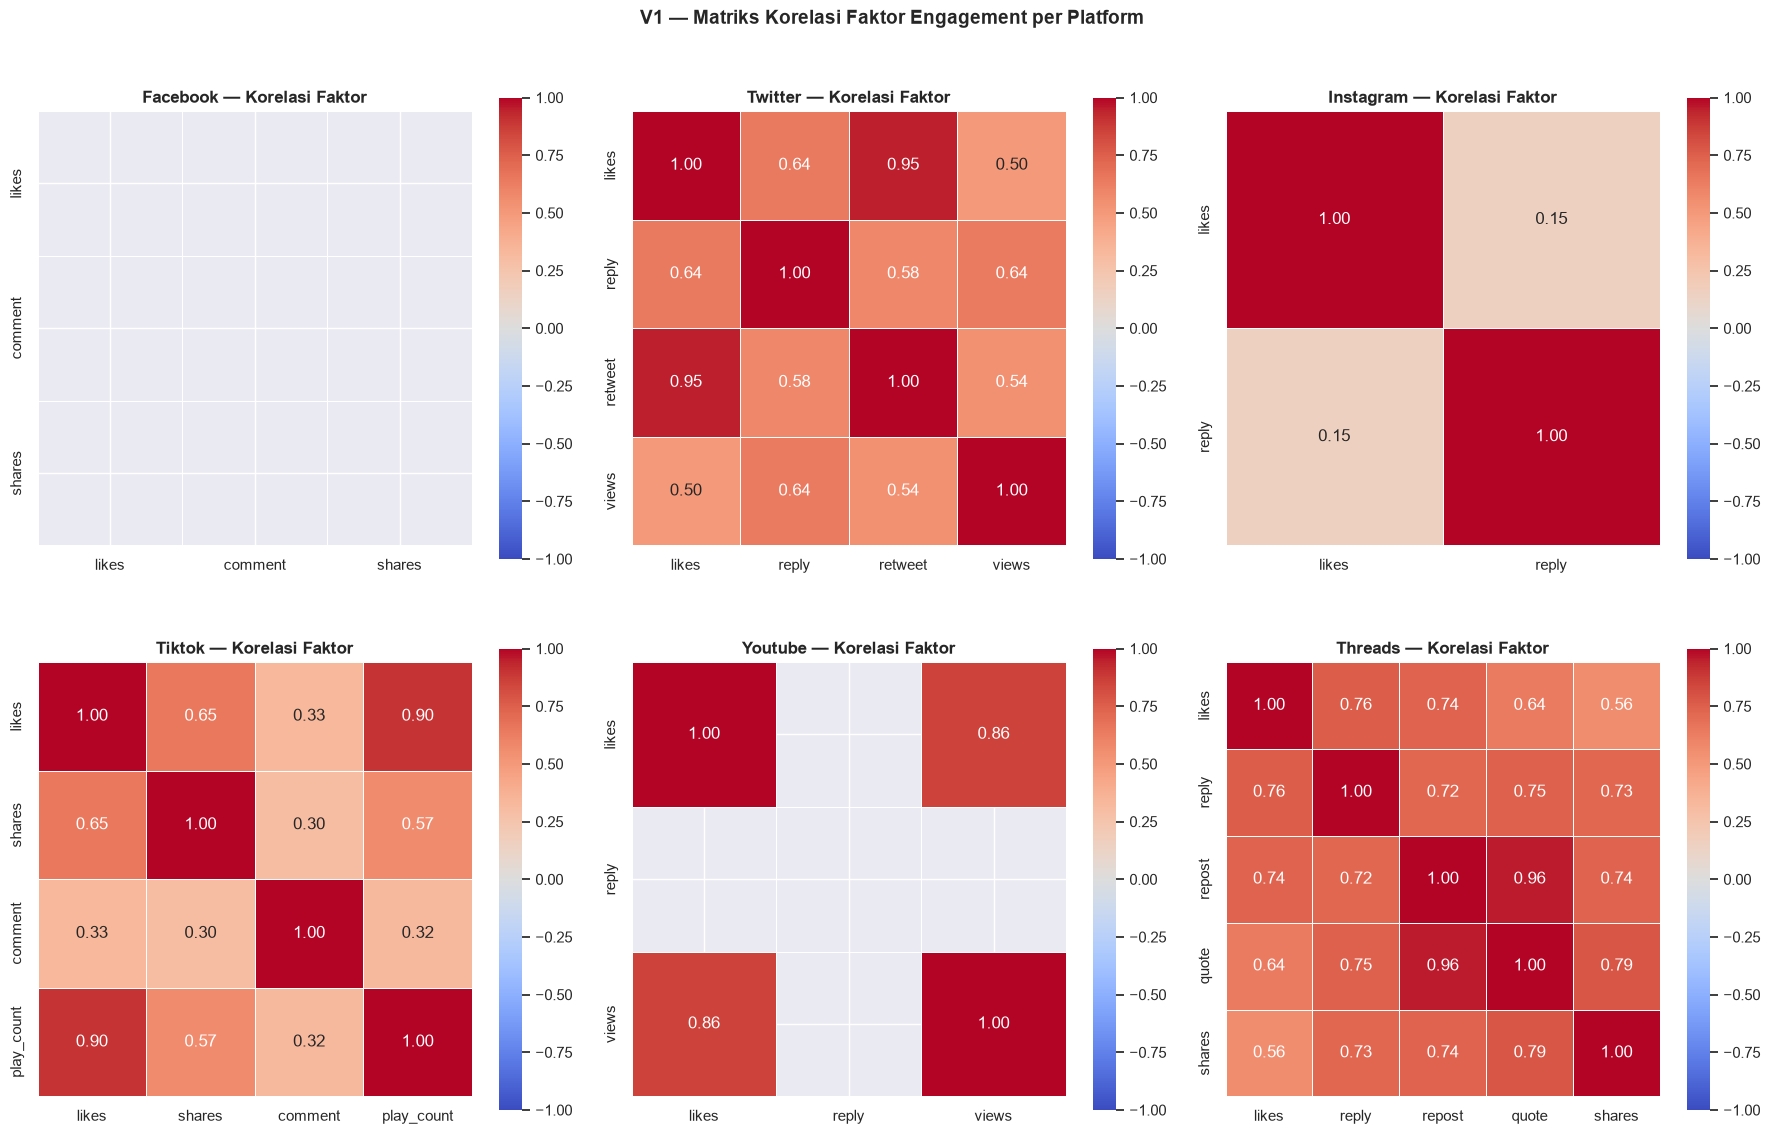

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (plat, res) in enumerate(results_v1.items()):
    ax = axes[i]
    df = res['df']
    eng_cols = [c for c in df.columns if c not in ['post_id', 'platform', 'engagement_score_v1']]
    if len(eng_cols) >= 2:
        corr = df[eng_cols].corr()
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
                    vmin=-1, vmax=1, square=True, linewidths=0.5,
                    cbar_kws={'shrink': 0.8})
    ax.set_title(f'{plat.capitalize()} — Korelasi Faktor', fontweight='bold')

plt.suptitle('V1 — Matriks Korelasi Faktor Engagement per Platform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_v1_korelasi_faktor.png', dpi=150, bbox_inches='tight')
plt.show()

## 🏁 Top 10 Posts per Platform berdasarkan Engagement Score V1

In [11]:
print('='*65)
print('🏆 TOP 10 POSTS — ENGAGEMENT SCORE V1')
print('='*65)

for plat, res in results_v1.items():
    df = res['df']
    top10 = df.nlargest(10, 'engagement_score_v1')
    eng_cols = [c for c in df.columns if c not in ['platform']]
    print(f'\n🥇 {plat.upper()}')
    print(top10[eng_cols].to_string(index=False))
    print()

🏆 TOP 10 POSTS — ENGAGEMENT SCORE V1

🥇 FACEBOOK
                                                                 post_id  likes  comment  shares  engagement_score_v1
UzpfSTEwMDA1MTI1NTYwMTI3NToxNjAyMTIzMzM4MTcyODM4OjE2MDIxMjMzMzgxNzI4Mzg=      0        0       0                  0.0
UzpfSTEwMDA0NDE2NTEyMjc4ODoxNzAwMDg0MjUxNDczNzI5OjE3MDAwODQyNTE0NzM3Mjk=      0        0       0                  0.0
UzpfSTEwMDA0NDE2NTEyMjc4ODoxNzAyNTk0MjkxMjIyNzI1OjE3MDI1OTQyOTEyMjI3MjU=      0        0       0                  0.0
UzpfSTEwMDA2NDY5MDYyODA3MzoxNDk5NzIzMDYyMTk0MDM0OjE0OTk3MjMwNjIxOTQwMzQ=      0        0       0                  0.0
UzpfSTEwMDA0NDE2NTEyMjc4ODoxNzAzMzk1MjA3ODA5MzAwOjE3MDMzOTUyMDc4MDkzMDA=      0        0       0                  0.0
UzpfSTEwMDA2NDY5MDYyODA3MzoxNTE3NzEyMDk3MDYxNzk3OjE1MTc3MTIwOTcwNjE3OTc=      0        0       0                  0.0
UzpfSTEwMDA0NDE2NTEyMjc4ODoxNzAxMDM2NDAxMzc4NTE0OjE3MDEwMzY0MDEzNzg1MTQ=      0        0       0                  0.0
UzpfSTE